# Report Figures Generation
This notebook contains production-grade data visualization code using Matplotlib and Seaborn. The generated figures will support the comparative analysis sections of the report.

In [1]:
# === GLOBAL PLOTTING CONFIGURATIONS ===
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set seaborn style
sns.set_theme(style="whitegrid")

# Set professional typography and sizes
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'figure.titlesize': 14,
    'figure.autolayout': True
})

# Create outputs figures directory if it doesn't exist
os.makedirs("../outputs/figures", exist_ok=True)
print("✅ Global plotting styles configured and figures directory verified.")

✅ Global plotting styles configured and figures directory verified.


✅ Saved Figure 1 to ../outputs/figures/baseline_retrieval_showdown.png


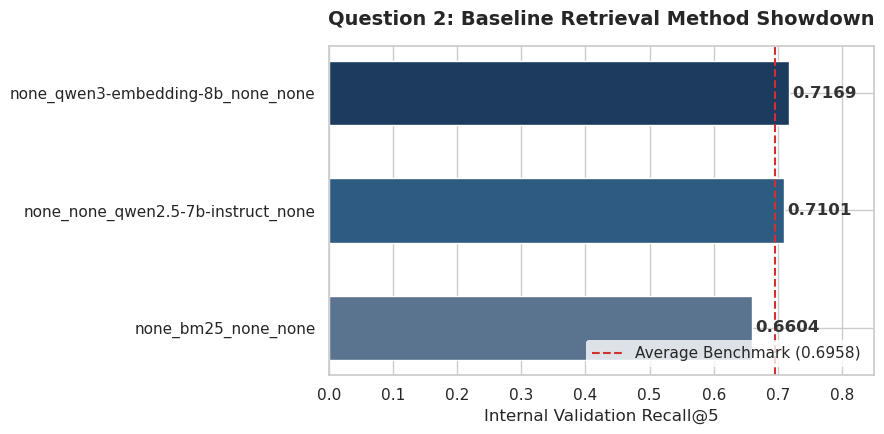

In [2]:
# === FIGURE 1: BASELINE RETRIEVAL METHOD SHOWDOWN ===
# Design: Horizontal bar chart comparing baseline recall scores with average benchmark annotation

baselines = {
    'none_bm25_none_none': 0.6604,
    'none_none_qwen2.5-7b-instruct_none': 0.7101,
    'none_qwen3-embedding-8b_none_none': 0.7169
}

# Load to DataFrame and sort in ascending order
df_baselines = pd.DataFrame(list(baselines.items()), columns=['Method', 'Recall@5'])
df_baselines = df_baselines.sort_values(by='Recall@5', ascending=True)

plt.figure(figsize=(9, 4.5))

# Deep corporate blue/gray palette
colors = ['#5A738E', '#2E5B82', '#1C3B5E']
bars = plt.barh(df_baselines['Method'], df_baselines['Recall@5'], color=colors, height=0.55)

# Add benchmark average line
avg_benchmark = df_baselines['Recall@5'].mean()
plt.axvline(avg_benchmark, color='#D32F2F', linestyle='--', linewidth=1.5, 
            label=f'Average Benchmark ({avg_benchmark:.4f})')

# Annotate exact value at the tip of each bar
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.005, bar.get_y() + bar.get_height()/2, f'{width:.4f}', 
             va='center', ha='left', fontweight='semibold', color='#333333')

plt.title('Question 2: Baseline Retrieval Method Showdown', pad=15, fontweight='bold')
plt.xlabel('Internal Validation Recall@5')
plt.xlim(0.0, 0.85)
plt.legend(loc='lower right', frameon=True, facecolor='white', edgecolor='none')
plt.tight_layout()

# Save figure
fig1_path = '../outputs/figures/baseline_retrieval_showdown.png'
plt.savefig(fig1_path, dpi=300)
print(f"✅ Saved Figure 1 to {fig1_path}")
plt.show()

✅ Saved Figure 2 to ../outputs/figures/hybrid_text_truncation_analysis.png


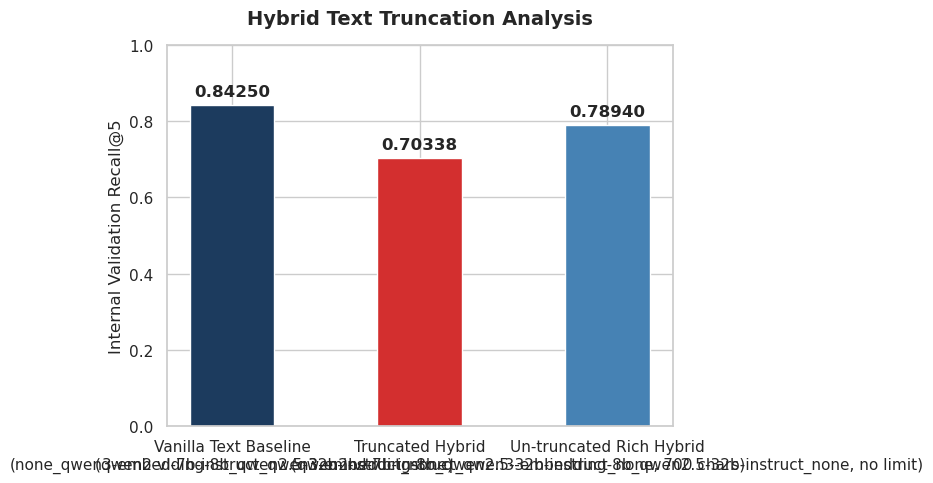

In [3]:
# === FIGURE 2: HYBRID TEXT TRUNCATION ANALYSIS ===
# Design: Column chart showing the trajectory of un-truncated rich text recovery vs truncation loss

categories = [
    'Vanilla Text Baseline\n(none_qwen3-embedding-8b_qwen2.5-32b-instruct_none)',
    'Truncated Hybrid\n(qwen2-vl-7b-instruct_qwen3-embedding-8b_qwen2.5-32b-instruct_none, 700 chars)',
    'Un-truncated Rich Hybrid\n(qwen2-vl-7b-instruct_qwen3-embedding-8b_qwen2.5-32b-instruct_none, no limit)'
]
scores = [0.8425, 0.70338, 0.7894]

plt.figure(figsize=(9, 5))

# Red/Orange highlight to show the performance drop due to truncation
colors = ['#1C3B5E', '#D32F2F', '#4682B4']
bars = plt.bar(categories, scores, color=colors, width=0.45)

# Annotate heights
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.015, f'{height:.5f}',
             va='bottom', ha='center', fontweight='semibold')

plt.title('Hybrid Text Truncation Analysis', pad=15, fontweight='bold')
plt.ylabel('Internal Validation Recall@5')
plt.ylim(0.0, 1.0)
plt.tight_layout()

# Save figure
fig2_path = '../outputs/figures/hybrid_text_truncation_analysis.png'
plt.savefig(fig2_path, dpi=300)
print(f"✅ Saved Figure 2 to {fig2_path}")
plt.show()

✅ Saved Figure 3 to ../outputs/figures/multimodal_vs_text_translation.png


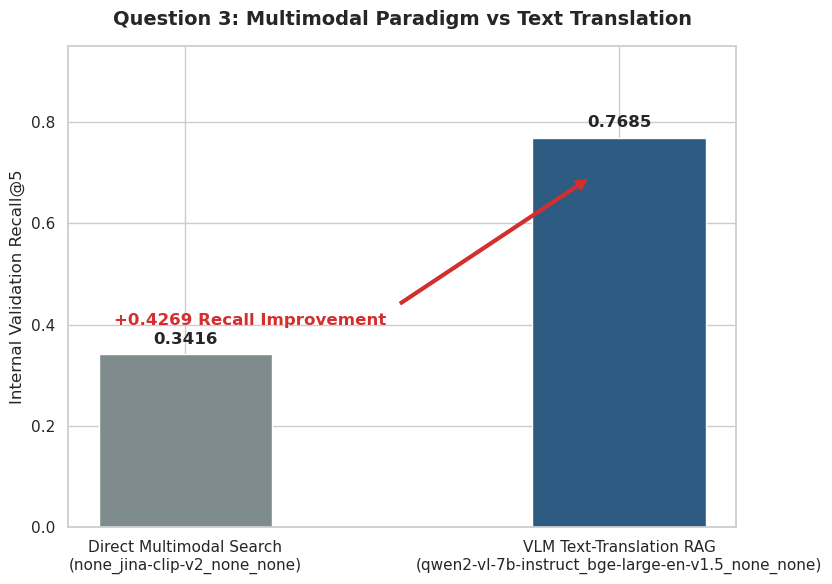

In [4]:
# === FIGURE 3: MULTIMODAL PARADIGM VS TEXT TRANSLATION ===
# Design: Column chart showing modality gap with red arrow annotation demonstrating performance gain

labels = [
    'Direct Multimodal Search\n(none_jina-clip-v2_none_none)', 
    'VLM Text-Translation RAG\n(qwen2-vl-7b-instruct_bge-large-en-v1.5_none_none)'
]
scores = [0.3416, 0.7685]

plt.figure(figsize=(8.5, 6))

# Neutral gray vs Deep blue contrast
colors = ['#7F8C8D', '#2E5B82']
bars = plt.bar(labels, scores, color=colors, width=0.4)

# Annotate bar values
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.015, f'{height:.4f}',
             va='bottom', ha='center', fontweight='semibold')

# Add red highlight arrow showing performance gain
plt.annotate(
    '+0.4269 Recall Improvement',
    xy=(0.95, 0.70),
    xytext=(0.15, 0.40),
    arrowprops=dict(facecolor='#D32F2F', edgecolor='#D32F2F', shrink=0.05, width=2, headwidth=8, headlength=8),
    fontsize=12,
    fontweight='bold',
    color='#D32F2F',
    ha='center'
)

plt.title('Question 3: Multimodal Paradigm vs Text Translation', pad=15, fontweight='bold')
plt.ylabel('Internal Validation Recall@5')
plt.ylim(0.0, 0.95)
plt.tight_layout()

# Save figure
fig3_path = '../outputs/figures/multimodal_vs_text_translation.png'
plt.savefig(fig3_path, dpi=300)
print(f"✅ Saved Figure 3 to {fig3_path}")
plt.show()